<a href="https://colab.research.google.com/github/1816x/Algoritmos-Aprendizaje-Automatico/blob/main/Practica%20Tema8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica Tema 8: fundamentos de clustering

**Estudiante:** Santiago Rivera Martínez  
**Materia:** Algoritmos de Aprendizaje Automático  
**Tema:** Aprendizaje no supervisado: K-Means, DBSCAN y clustering jerárquico

---

## Objetivo

En esta práctica analizo cómo distintos algoritmos identifican grupos cuando los datos no tienen una etiqueta conocida. Desarrollo los cinco retos solicitados y comparo el efecto del escalado, el número de grupos, la densidad y el criterio de enlace.

> El notebook está preparado para ejecutarse de arriba hacia abajo en Google Colab sin subir archivos ni descargar un dataset.

## 0. Preparación del entorno

Importo las bibliotecas necesarias y fijo una semilla para que los resultados puedan reproducirse.

In [1]:
# import the required libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# set a reproducible seed and a consistent visual style
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

print("Environment ready.")

Environment ready.


# Módulo 1. Fundamentos y preprocesamiento

## Reto 1. El impacto de no escalar las variables

### Planteamiento

Creo datos con dos variables: edad e ingreso anual. La edad se mide en unidades, mientras que el ingreso se expresa en miles. Como K-Means calcula distancias, el ingreso puede dominar el resultado únicamente por tener números más grandes.

Compararé las asignaciones de K-Means antes y después de aplicar `StandardScaler`.

In [2]:
# create data with variables on very different scales
ages = np.array([20, 21, 22, 24, 25, 26, 55, 56, 58, 60, 61, 63])
annual_income = np.array([
    30000, 80000, 40000, 100000, 60000, 120000,
    35000, 85000, 45000, 105000, 65000, 125000
])

X_scale = np.column_stack([ages, annual_income])

# fit k-means without scaling
kmeans_raw = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_raw = kmeans_raw.fit_predict(X_scale)

# standardize both variables and fit k-means again
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_scale)
kmeans_scaled = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

scale_results = pd.DataFrame({
    "age": ages,
    "annual_income": annual_income,
    "cluster_without_scaling": labels_raw,
    "cluster_with_scaling": labels_scaled,
})

scale_results

,age,annual_income,cluster_without_scaling,cluster_with_scaling
0,20,30000,0,0
1,21,80000,1,0
2,22,40000,0,0
3,24,100000,1,0
4,25,60000,0,0
5,26,120000,1,0
6,55,35000,0,1
7,56,85000,1,1
8,58,45000,0,1
9,60,105000,1,1


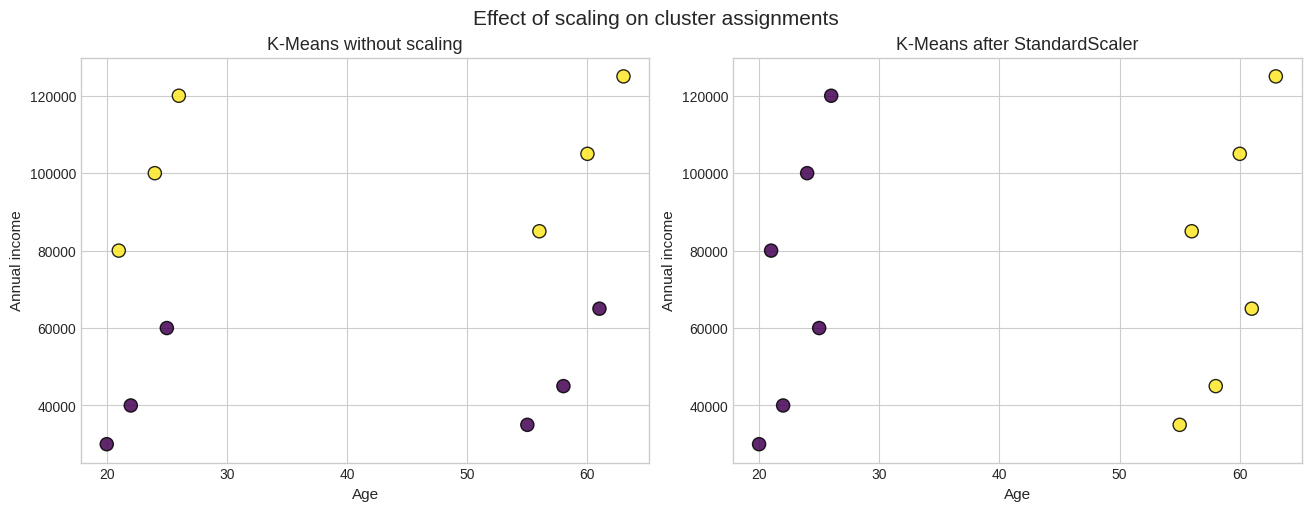

In [3]:
# compare the assignments in the original unit space
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].scatter(
    ages, annual_income, c=labels_raw, cmap="viridis",
    s=90, edgecolor="black", alpha=0.85
)
axes[0].set_title("K-Means without scaling")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Annual income")

axes[1].scatter(
    ages, annual_income, c=labels_scaled, cmap="viridis",
    s=90, edgecolor="black", alpha=0.85
)
axes[1].set_title("K-Means after StandardScaler")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Annual income")

plt.suptitle("Effect of scaling on cluster assignments", fontsize=15)
plt.show()

In [4]:
# compare one distance before and after scaling
raw_difference = np.abs(X_scale[0] - X_scale[1])
scaled_difference = np.abs(X_scaled[0] - X_scaled[1])

distance_comparison = pd.DataFrame({
    "variable": ["age", "annual_income"],
    "raw_absolute_difference": raw_difference,
    "scaled_absolute_difference": scaled_difference.round(3),
})

print("K-Means centroids without scaling:")
print(kmeans_raw.cluster_centers_)
print("\nK-Means centroids in standardized space:")
print(kmeans_scaled.cluster_centers_.round(3))
distance_comparison

K-Means centroids without scaling:
[[4.01666667e+01 4.58333333e+04]
 [4.16666667e+01 1.02500000e+05]]

K-Means centroids in standardized space:
[[-0.99  -0.078]
 [ 0.99   0.078]]


,variable,raw_absolute_difference,scaled_absolute_difference
0,age,1,0.055
1,annual_income,50000,1.565


### Interpretación del reto 1

Sin escalado, una diferencia de decenas de miles en ingreso pesa mucho más que una diferencia de varios años de edad. Por eso, K-Means divide principalmente por ingreso. Después del escalado, ambas variables quedan expresadas en desviaciones respecto a su media y la edad también influye en la formación de los grupos.

**Conclusión:** escalar no es un detalle visual; cambia el significado de la distancia y puede cambiar por completo los grupos detectados.

# Módulo 2. K-Means y su funcionamiento iterativo

## Reto 2. Simulación manual de una iteración de K-Means

Los puntos son (A=2), (B=4), (C=10) y (D=12). Se usarán dos centroides iniciales: (C_1=3) y (C_2=11).

En una iteración debo:

1. Calcular la distancia absoluta de cada punto a cada centroide.
2. Asignar cada punto al centroide más cercano.
3. Calcular la media de los puntos de cada grupo para obtener los nuevos centroides.

In [5]:
# define the points and initial centroids
points = np.array([2, 4, 10, 12], dtype=float)
point_names = np.array(["A", "B", "C", "D"])
c1, c2 = 3.0, 11.0

# calculate distances to each centroid
distance_to_c1 = np.abs(points - c1)
distance_to_c2 = np.abs(points - c2)

# assign each point to its nearest centroid
assignments = np.where(distance_to_c1 <= distance_to_c2, "C1", "C2")

iteration_table = pd.DataFrame({
    "point": point_names,
    "value": points,
    "distance_to_C1": distance_to_c1,
    "distance_to_C2": distance_to_c2,
    "assigned_cluster": assignments,
})

# recalculate each centroid as the mean of its assigned points
new_c1 = points[assignments == "C1"].mean()
new_c2 = points[assignments == "C2"].mean()

iteration_table

,point,value,distance_to_C1,distance_to_C2,assigned_cluster
0,A,2.0,1.0,9.0,C1
1,B,4.0,1.0,7.0,C1
2,C,10.0,7.0,1.0,C2
3,D,12.0,9.0,1.0,C2


Initial centroids: C1 = 3.0, C2 = 11.0
New centroid C1: mean of [2.0, 4.0] = 3.0
New centroid C2: mean of [10.0, 12.0] = 11.0


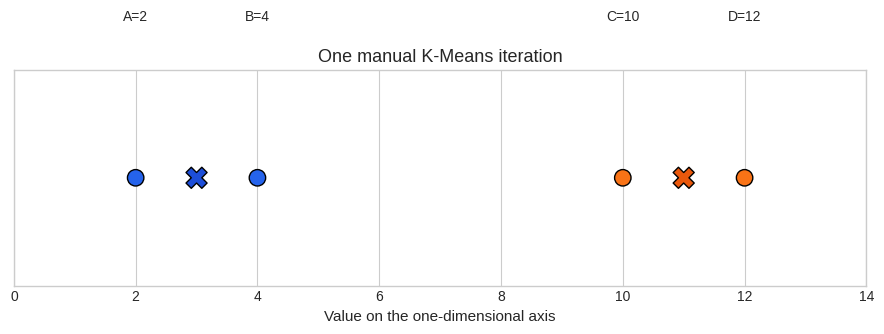

In [6]:
# show the result of the manual iteration
print(f"Initial centroids: C1 = {c1:.1f}, C2 = {c2:.1f}")
print(f"New centroid C1: mean of {points[assignments == 'C1'].tolist()} = {new_c1:.1f}")
print(f"New centroid C2: mean of {points[assignments == 'C2'].tolist()} = {new_c2:.1f}")

fig, ax = plt.subplots(figsize=(11, 2.8))
colors = np.where(assignments == "C1", "#2563eb", "#f97316")
ax.scatter(points, np.zeros_like(points), c=colors, s=140, edgecolor="black", zorder=3)

for name, value in zip(point_names, points):
    ax.text(value, 0.08, f"{name}={value:g}", ha="center")

ax.scatter([new_c1, new_c2], [0, 0], marker="X", s=230, c=["#1d4ed8", "#ea580c"], edgecolor="black")
ax.set_yticks([])
ax.set_xlim(0, 14)
ax.set_title("One manual K-Means iteration")
ax.set_xlabel("Value on the one-dimensional axis")
plt.show()

### Resultado del reto 2

- Los puntos 2 y 4 se asignan a (C_1).
- Los puntos 10 y 12 se asignan a (C_2).
- El nuevo (C_1=(2+4)/2=3).
- El nuevo (C_2=(10+12)/2=11).

Los centroides no cambian porque ya se encontraban exactamente en la media de sus respectivos grupos. Esto significa que el algoritmo ya convergió para estos datos.

## Reto 3. Sensibilidad al número de clusters (k)

Creo un conjunto con cuatro grupos naturales. Luego obligo a K-Means a encontrar 2, 4 y 6 grupos para observar qué ocurre cuando (k) es menor, correcto o mayor que la estructura real.

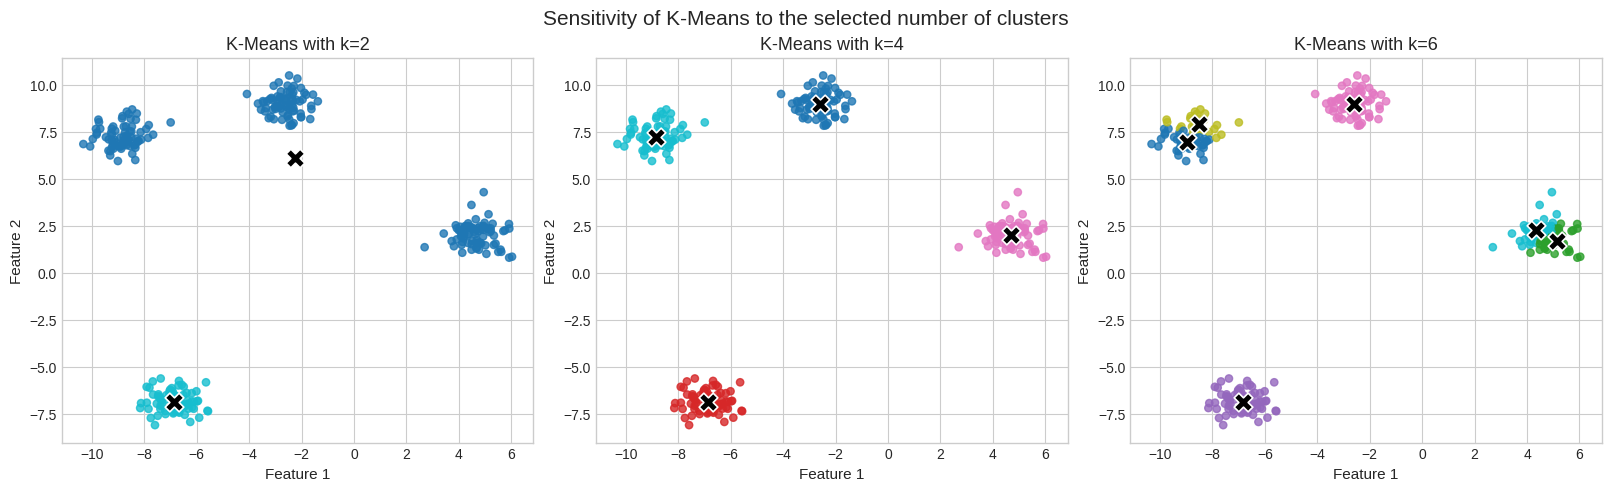

,k,inertia
0,2,9051.82
1,4,203.89
2,6,165.72


In [7]:
# generate a synthetic dataset with four natural groups
X_blobs, true_blob_labels = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.6,
    random_state=RANDOM_STATE,
)

# fit and visualize different values of k
k_values = [2, 4, 6]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
k_summary = []

for ax, k in zip(axes, k_values):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_blobs)
    k_summary.append({"k": k, "inertia": model.inertia_})

    ax.scatter(
        X_blobs[:, 0], X_blobs[:, 1], c=labels,
        cmap="tab10", s=28, alpha=0.8
    )
    ax.scatter(
        model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
        marker="X", s=180, c="black", edgecolor="white", linewidth=1.2
    )
    ax.set_title(f"K-Means with k={k}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle("Sensitivity of K-Means to the selected number of clusters", fontsize=15)
plt.show()

pd.DataFrame(k_summary).round(2)

### Interpretación del reto 3

- **(k=2):** une grupos naturales distintos y pierde información de la estructura.
- **(k=4):** recupera visualmente los cuatro grupos que se usaron para crear los datos.
- **(k=6):** fragmenta algunos grupos naturales en subdivisiones artificiales.

**Conclusión:** K-Means siempre produce exactamente el número de grupos solicitado, aunque ese número no represente bien los datos. El valor de (k) debe justificarse y no elegirse al azar.

# Módulo 3. DBSCAN y agrupamiento por densidad

## Reto 4. Sensibilidad al radio epsilon y detección de ruido

DBSCAN considera que existe una región densa cuando un punto tiene suficientes vecinos dentro de un radio determinado. Compararé `eps=0.7` y `eps=0.3`, como pide el reto, y añadiré `eps=0.15` para comprobar un caso todavía más estricto. Mantendré `min_samples=5`.

En DBSCAN la etiqueta (-1) representa ruido: observaciones que no pudieron incorporarse a una región suficientemente densa.

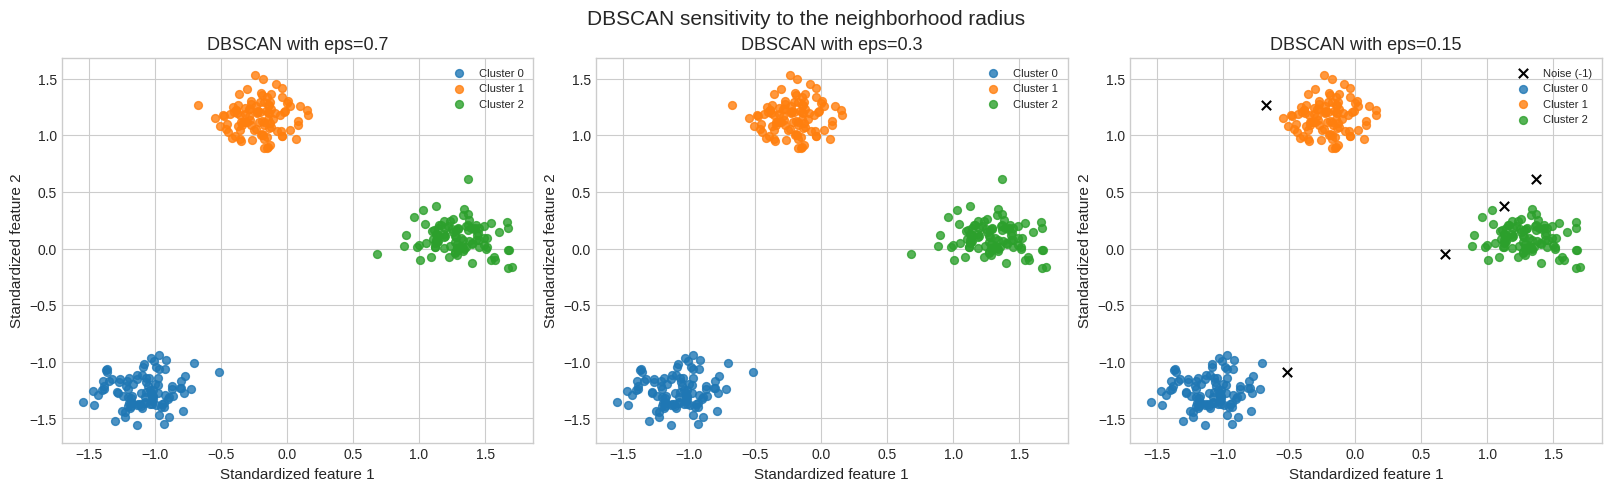

,eps,clusters_detected,noise_points,noise_percentage
0,0.70,3,0,0.00
1,0.30,3,0,0.00
2,0.15,3,5,1.67


In [8]:
# generate and standardize the data required by the exercise
X_db, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.9,
    random_state=RANDOM_STATE,
)
X_db = StandardScaler().fit_transform(X_db)

# compare the requested radii and one stricter case
eps_values = [0.7, 0.3, 0.15]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
dbscan_summary = []

for ax, eps in zip(axes, eps_values):
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_db)

    noise_count = int(np.sum(labels == -1))
    cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
    dbscan_summary.append({
        "eps": eps,
        "clusters_detected": cluster_count,
        "noise_points": noise_count,
        "noise_percentage": 100 * noise_count / len(labels),
    })

    for label in np.unique(labels):
        mask = labels == label
        if label == -1:
            ax.scatter(
                X_db[mask, 0], X_db[mask, 1],
                c="black", marker="x", s=45, label="Noise (-1)"
            )
        else:
            ax.scatter(
                X_db[mask, 0], X_db[mask, 1],
                s=32, alpha=0.8, label=f"Cluster {label}"
            )

    ax.set_title(f"DBSCAN with eps={eps}")
    ax.set_xlabel("Standardized feature 1")
    ax.set_ylabel("Standardized feature 2")
    ax.legend(fontsize=8, loc="best")

plt.suptitle("DBSCAN sensitivity to the neighborhood radius", fontsize=15)
plt.show()

dbscan_summary = pd.DataFrame(dbscan_summary)
dbscan_summary.round(2)

In [9]:
# report the requested noise counts explicitly
for row in dbscan_summary.itertuples(index=False):
    print(
        f"eps={row.eps}: {row.clusters_detected} clusters and "
        f"{row.noise_points} noise points ({row.noise_percentage:.1f}%)."
    )

eps=0.7: 3 clusters and 0 noise points (0.0%).
eps=0.3: 3 clusters and 0 noise points (0.0%).
eps=0.15: 3 clusters and 5 noise points (1.7%).


### Interpretación del reto 4

Con un radio más amplio, cada punto puede encontrar más vecinos y es más fácil que se conecten regiones densas. En este conjunto particular, `eps=0.7` y `eps=0.3` conservan los tres clusters sin ruido porque las regiones siguen siendo suficientemente compactas. Al reducir el radio a `eps=0.15`, la condición sí se vuelve lo bastante estricta para que aparezcan puntos aislados.

**Conclusión:** un `eps` demasiado grande puede fusionar estructuras; uno demasiado pequeño puede convertir observaciones válidas en ruido. DBSCAN no exige indicar el número de clusters, pero sí exige elegir parámetros coherentes con la escala y densidad de los datos.

# Módulo 4. Clustering jerárquico y dendrogramas

## Reto 5. Comparación de criterios de enlace

El clustering jerárquico aglomerativo comienza con cada punto por separado y después fusiona grupos. El criterio de enlace define cómo se calcula la distancia entre dos grupos.

- **Ward:** busca fusiones que aumenten lo menos posible la variación interna.
- **Complete:** usa la distancia entre los puntos más lejanos de ambos grupos.
- **Average:** utiliza el promedio de todas las distancias entre ambos grupos.

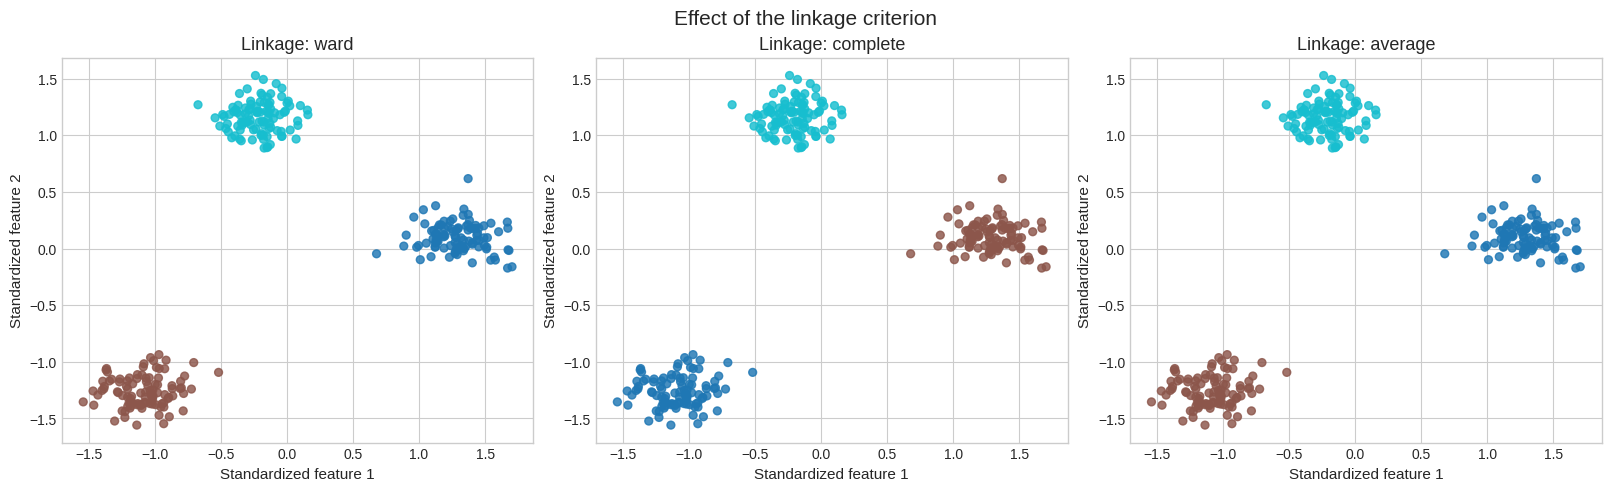

,ward,complete,average
cluster 0,100,100,100
cluster 1,100,100,100
cluster 2,100,100,100


In [10]:
# compare three linkage criteria on the same standardized dataset
linkage_methods = ["ward", "complete", "average"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
hierarchical_results = {}

for ax, method in zip(axes, linkage_methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_db)
    hierarchical_results[method] = labels

    ax.scatter(
        X_db[:, 0], X_db[:, 1], c=labels,
        cmap="tab10", s=32, alpha=0.82
    )
    ax.set_title(f"Linkage: {method}")
    ax.set_xlabel("Standardized feature 1")
    ax.set_ylabel("Standardized feature 2")

plt.suptitle("Effect of the linkage criterion", fontsize=15)
plt.show()

pd.DataFrame({
    method: np.bincount(labels)
    for method, labels in hierarchical_results.items()
}, index=["cluster 0", "cluster 1", "cluster 2"])

### Dendrograma con enlace Ward

El dendrograma muestra el orden y la distancia a la que se fusionan los grupos. Las uniones cercanas representan observaciones similares; las uniones altas indican que se están combinando estructuras más diferentes.

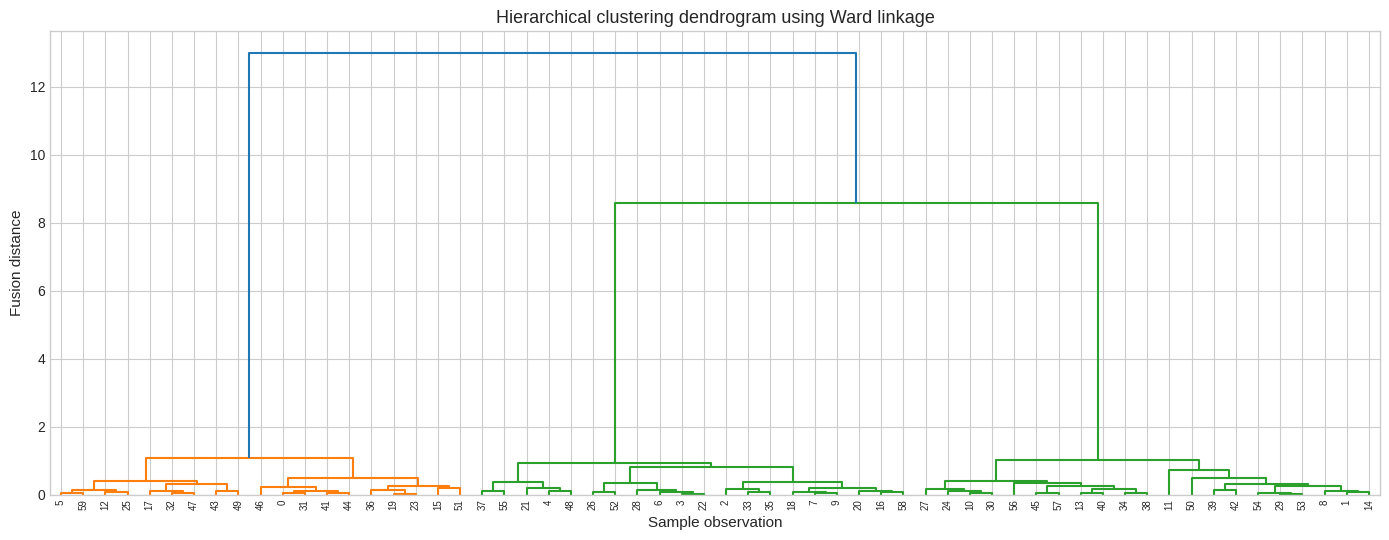

In [11]:
# build a ward dendrogram from a readable sample of the data
sample_indices = np.linspace(0, len(X_db) - 1, 60, dtype=int)
X_dendrogram = X_db[sample_indices]
ward_matrix = linkage(X_dendrogram, method="ward")

plt.figure(figsize=(14, 5.5))
dendrogram(
    ward_matrix,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=None,
)
plt.title("Hierarchical clustering dendrogram using Ward linkage")
plt.xlabel("Sample observation")
plt.ylabel("Fusion distance")
plt.tight_layout()
plt.show()

### Interpretación del reto 5

Los tres métodos reciben exactamente los mismos datos y el mismo número final de clusters, pero sus fronteras pueden cambiar porque cada uno define de manera distinta la cercanía entre grupos. Ward suele producir grupos compactos y equilibrados; complete evita unir grupos si existe una separación grande entre alguno de sus puntos; average ofrece un comportamiento intermedio.

**Conclusión:** el enlace no es solamente una opción del programa. Es una suposición sobre la forma en que debe construirse la jerarquía.

# Comparación final de algoritmos

| Aspecto | K-Means | DBSCAN | Jerárquico |
|---|---|---|---|
| Idea principal | Cercanía a centroides | Densidad local | Fusiones sucesivas |
| Parámetros clave | Número (k) de clusters | `eps` y `min_samples` | Enlace y número de clusters o corte |
| Forma favorecida | Grupos compactos y aproximadamente redondos | Formas arbitrarias y regiones densas | Estructura multinivel |
| Ruido explícito | No | Sí, etiqueta (-1) | No de forma automática |
| Resultado interpretable | Centroides y asignaciones | Núcleo, frontera y ruido | Dendrograma y jerarquía |
| Principal riesgo | Elegir mal (k) o no escalar | Elegir mal el radio o densidad mínima | Elegir un enlace inadecuado |

# Preguntas de reflexión

### 1. ¿Por qué no existe un algoritmo de clustering mejor en todos los casos?

Porque cada algoritmo utiliza una noción diferente de grupo. K-Means busca cercanía a centroides, DBSCAN busca regiones densas y el método jerárquico construye una estructura de fusiones. La geometría, escala, ruido y objetivo del análisis determinan cuál resulta más adecuado.

### 2. ¿Qué pasaría con K-Means si no se escalan las variables?

Las variables con magnitudes numéricas grandes dominarían la distancia. Los clusters podrían representar principalmente esas variables y dejar casi sin influencia a las de menor escala, aunque estas últimas fueran relevantes para el problema.

### 3. ¿En qué tipo de datos DBSCAN sería preferible a K-Means?

En datos con clusters de forma irregular, cuando no se conoce de antemano la cantidad de grupos y cuando se desea detectar observaciones aisladas como ruido. Su desempeño depende de que las densidades puedan describirse razonablemente con los parámetros seleccionados.

# Conclusiones generales

En esta práctica comprobé que el resultado del clustering depende tanto del algoritmo como de las decisiones previas. El escalado modifica la distancia, el valor de (k) puede unir o fragmentar grupos, `eps` controla qué tan estricta es la densidad y el criterio de enlace cambia la jerarquía.

Por lo tanto, una solución de aprendizaje no supervisado no debe evaluarse únicamente porque produce colores o grupos visuales. Primero se debe justificar la representación de los datos, la medida de similitud y la noción de grupo que corresponde al problema.

# Glosario de acrónimos y abreviaciones

- **DBSCAN — Density-Based Spatial Clustering of Applications with Noise:** algoritmo que forma clusters a partir de regiones densas y marca como ruido los puntos aislados. Es como encontrar grupos de personas en una plaza observando dónde hay suficiente gente junta.
- **1D — One-Dimensional:** espacio con una sola dimensión o variable. Es como colocar puntos sobre una única regla.
- **`eps` — epsilon:** abreviación usada para el radio máximo de vecindad en DBSCAN. Es como el alcance de un círculo alrededor de cada punto.
- **`min_samples` — minimum samples:** cantidad mínima de observaciones vecinas necesaria para considerar que una zona es densa.